In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bilby.gw.transdimensional_source_models import make_signal_model
import bilby

In [2]:
ifo_list = bilby.gw.detector.InterferometerList(["H1", "L1", "V1"])
N = 3
signal_model = make_signal_model(N, ifo_list)

In [3]:
f_min = 20.0
sampling_frequency = 2048.0
f_max = sampling_frequency / 2.0
T = 16.0
freqs = np.arange(f_min, f_max, 1.0 / T)

In [25]:
N = 3

# Intrinsic
Q0 = 5.0
Q1 = 50.0
Q2 = 20.0

SNR0 = 10.0
SNR1 = 0.01
SNR2 = 30.0

f0_0 = 20.0
f0_1 = 10.0
f0_2 = 200.0

t0_0 = 4.0
t0_1 = 8.0
t0_2 = 12.0

phi0_0 = 0.0
phi0_1 = np.pi / 4.0
phi0_2 = np.pi / 2.0


# Extrinsic
geocent_time = 0.0
psi = 0.0
ra = 0.0
dec = 0.0
e = 0.0

wavelet_kwargs = {
    'n': N,
    'Q0': Q0,
    'Q1': Q1,
    'Q2': Q2,
    'SNR0': SNR0,
    'SNR1': SNR1,
    'SNR2': SNR2,
    'f0': f0_0,
    'f1': f0_1,
    'f2': f0_2,
    'dt0': t0_0,
    'dt1': t0_1,
    'dt2': t0_2,
    'phi0': phi0_0,
    'phi1': phi0_1,
    'phi2': phi0_2,
    'geocent_time': geocent_time,
    'psi': psi,
    'ra': ra,
    'dec': dec,
    'e': e,
}

In [26]:
wavelet_strain= signal_model(freqs, **wavelet_kwargs)
wavelet_hp, wavelet_hc = wavelet_strain['plus'], wavelet_strain['cross']

In [27]:
waveform_arguments = dict(
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)
waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
    duration=T,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=signal_model,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
    parameters=wavelet_kwargs
)

11:12 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=16.0, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.transdimensional_source_models.signal_model_3components, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'minimum_frequency': 20.0, 'maximum_frequency': 1024.0})


In [28]:
strain_from_generator = waveform_generator.time_domain_strain()
time_array = waveform_generator.time_array
hp, hc = strain_from_generator['plus'], strain_from_generator['cross']

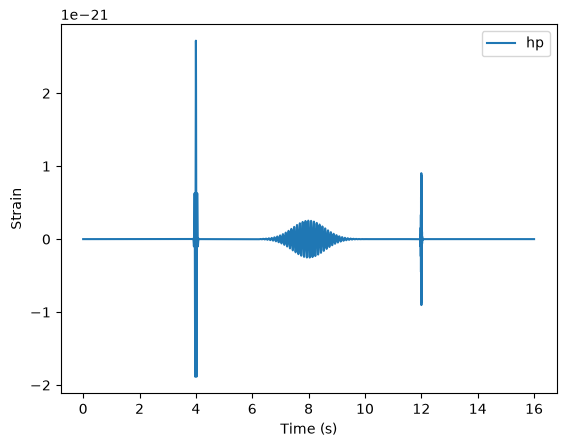

In [29]:
plt.plot(time_array, hp, label='hp')
# plt.plot(freqs, wavelet_hc, label='hc')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.show()